# Семинар 1

Доп. материалы:


*   [Внутри виртуальной машины Python. Часть 1](https://habr.com/ru/articles/501338/)
*   [План избавление от GIL в CPython](https://www.opennet.ru/opennews/art.shtml?num=59518)
*   [Differences between PyPy and CPython](https://doc.pypy.org/en/latest/cpython_differences.html)
*   [Как работает Python: интерпретатор, байт-код, PVM](https://pythonchik.ru/osnovy/kak-rabotaet-python-interpretator)
*   [Дизайн и реализация виртуальной машины CPython](https://habr.com/ru/companies/beget/articles/850578/)
*   [C/C++ из Python (ctypes)](https://habr.com/ru/articles/466499/)

Python - это один из наиболее популярных языков программирования используемых для решения задач анализа данных, машинного обучения, веб-разработки и других задач. Это высокоуровневый объектно-ориентированный язык программирования с динамической типизацией и автоматическим управлением памятью.

Обычно когда говорят про Python подразумевают CPython, но не всегда

## Интерактивный интерпретатор и Google Colab

Google Colab работате на основе Jupyter Notebook. Когда вы открываете ноутбук в Colab, Google предоставляет удалённый сервер с предустановленной Python-средой, работающий на виртуальной машине (VM). Код выполняется на CPU, GPU или TPU этой VM, а не на вашем локальном процессоре.

Забавный факт:

Исполнив `!python3` можем запустить `интерактивный Python-интерпретатор` отдельно от основного Python-интерпретатора на удалённом сервере Google, который используется для выполнения ячеек в Colab. Это значит, что код, который выполняется в этом процессе, не взаимодействует напрямую с переменными и данными в Colab.

In [ ]:
_a = 1  # посмотрим сможем ли мы работать с этой переменной через интерактивный Python-интерпретатор

In [2]:
!python3

Python 3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> 
KeyboardInterrupt
>>> 
Traceback (most recent call last):
  File "<stdin>", line 0, in <module>
KeyboardInterrupt
>>> 

При исполнении `!python3` происходит следующее:

1. `!` указывает на выполнение команды в терминале, а не в интерпретаторе Python. Запускает внешний процесс
2. `!python3` запускает внешнюю команду `python3` из `/usr/bin/` в командной строке, как если бы вы открыли терминал и ввели `python3`
3. `python3` вызывает активную версию Python 3, настроенную по умолчанию на вашем окружении.
4. python запускается как самостоятельный процесс, не связанный напрямую с уже запущенной версией Python в Colab.
5. открывается `интерактивный интерпретатор Python`. Вы увидите приглашение (например, `>>>`), указывающее на то, что вы находитесь в командной оболочке Python
6. пока активен этот интерпретатор, вы можете вводить команды Python в терминал, и он будет выполнять их в режиме реального времени
7. пока интерпретатор Python активен, Colab ждет его завершения
8. введите `exit()` для завершение процесса

##### Давайте разберёмся какой Python у нас запускается: `системного Python` или `пользовательский Python`:

Напомним, что у нас есть
1. Python установленный из официальных репозиториев вашей OS (например, через `apt`)

In [ ]:
!cd /usr/lib/ && ls -A | grep pyth

python2.7
python3
python3.10
python3.11


In [ ]:
!cd /usr/bin/ && ls -A | grep pyth  # исполняемые файлы

python3
python3.10
python3.10-config
python3.11
python3.11-config
python3-config
x86_64-linux-gnu-python3.10-config
x86_64-linux-gnu-python3.11-config
x86_64-linux-gnu-python3-config


2. пользовательская версия Python, установленная отдельно, например, из исходного кода или через менеджеры версий, такие как `pyenv`

In [ ]:
!cd /usr/local/lib/ && ls -A | grep pyth

python3.10


In [ ]:
!cd /usr/local/bin/ && ls -A | grep pyth  # исполняемые файлы

ipython
ipython3
python


 Посмотрим какая версия python исполняется из терминала:

1. Когда из терминала вы используете команду `python3` вы обращаетесь к `системной версии Python`

In [ ]:
!which python3

/usr/bin/python3


2. Когда из терминала вы используете команду `python` (без 3) вы обращаетесь к `пользовательской версии Python`

In [ ]:
!which python

/usr/local/bin/python


3. В colab мы также можем посмотреть какой исполняемый файл используется:

In [ ]:
import sys

print("Путь к исполняемому файлу Python:", sys.executable)

Путь к исполняемому файлу Python: /usr/bin/python3


In [ ]:
!python3

Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> exit()


In [ ]:
!python

Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> exit()


##### **Как работает Google Colab / Jupyter Notebook**

0. **Запуск ноутбука**:
  - При открытии ноутбука запускается ядро Python (обычно `/usr/bin/python3`), которое будет выполнять ваш код.
1. **Выполнение кода в ячейке**:
  - Когда вы запускаете код в ячейке, ноутбук передаёт этот код ядру Python через специальный коммуникационный протокол (обычно это [ZeroMQ](https://zeromq.org/)), что обеспечивает асинхронное и двустороннее общение между интерфейсом ноутбука и ядром.
2. **Исполнение кода ядром**:
  - Ядро Python получает код, интерпретирует и выполняет его.
  - Во время выполнения ядро может генерировать: результаты вычислений, ошибки, предупреждения и другую информацию.
3. **Возврат результатов**:
  - Ядро отправляет результаты выполнения обратно в ноутбук через тот же коммуникационный канал.
  - Результаты могут включать в себя стандартный вывод (`stdout`), ошибки (`stderr`), графики, таблицы и другие визуализации.
4. **Отображение результатов в ноутбуке**:
  - Ноутбук получает эти результаты и отображает их в ячейке вывода под исходным кодом.

Ноутбук не выполняет код самостоятельно, а служит интерфейсом между пользователем и ядром Python. Ядро работает в отдельном процессе, обеспечивая изоляцию и независимость выполнения кода.

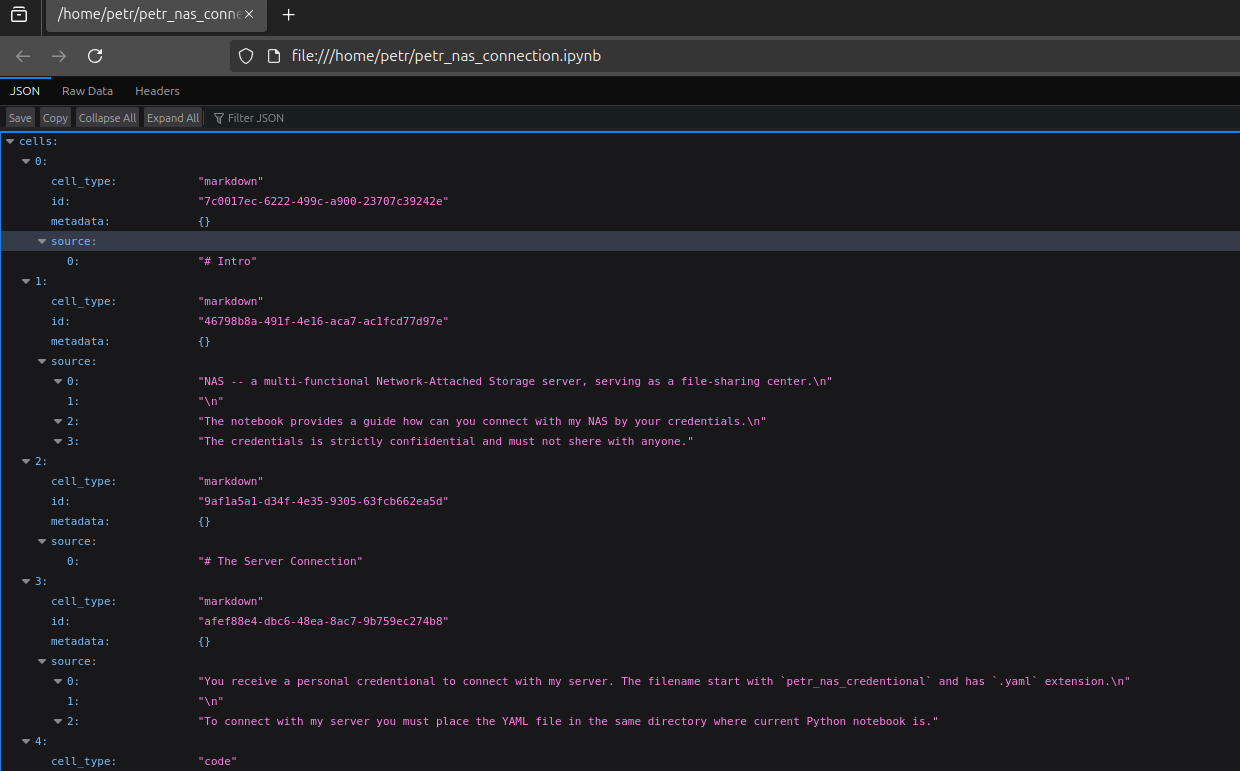

## О процессе трансляции

Python code

In [3]:
def summator(a: int, b: int):
    print(a + b)
    x = {10}
    y = {20}
    # c = x * y
    p = x | y
    print(None)
    return a + b

summator(1, 5)

6
None


6

In [4]:
from dis import dis

dis(summator)

  1           0 RESUME                   0

  2           2 LOAD_GLOBAL              1 (NULL + print)
             12 LOAD_FAST                0 (a)
             14 LOAD_FAST                1 (b)
             16 BINARY_OP                0 (+)
             20 CALL                     1
             28 POP_TOP

  3          30 LOAD_CONST               1 (10)
             32 BUILD_SET                1
             34 STORE_FAST               2 (x)

  4          36 LOAD_CONST               2 (20)
             38 BUILD_SET                1
             40 STORE_FAST               3 (y)

  6          42 LOAD_FAST                2 (x)
             44 LOAD_FAST                3 (y)
             46 BINARY_OP                7 (|)
             50 STORE_FAST               4 (p)

  7          52 LOAD_GLOBAL              1 (NULL + print)
             62 LOAD_CONST               0 (None)
             64 CALL                     1
             72 POP_TOP

  8          74 LOAD_FAST                0 (a)

### Лексический анализатор (Lexer):

Модуль `tokenize` предоставляет лексический сканер для исходного кода Python, реализованный на Python. Сканер в этом модуле также возвращает комментарии в виде токенов

Модуль `io` предоставляет основные возможности Python для работы с различными типами ввода-вывода. Существует три основных типа ввода-вывода: text I/O, binary I/O and raw I/O

In [5]:
import tokenize
from io import BytesIO

code = b"""def summator(a, b):
    print(a + b)
    return a + b"""

# help(code)
# code
tokens = tokenize.tokenize(BytesIO(code).readline)

for token in tokens:
    print(token)


TokenInfo(type=67 (ENCODING), string='utf-8', start=(0, 0), end=(0, 0), line='')
TokenInfo(type=1 (NAME), string='def', start=(1, 0), end=(1, 3), line='def summator(a, b):\n')
TokenInfo(type=1 (NAME), string='summator', start=(1, 4), end=(1, 12), line='def summator(a, b):\n')
TokenInfo(type=55 (OP), string='(', start=(1, 12), end=(1, 13), line='def summator(a, b):\n')
TokenInfo(type=1 (NAME), string='a', start=(1, 13), end=(1, 14), line='def summator(a, b):\n')
TokenInfo(type=55 (OP), string=',', start=(1, 14), end=(1, 15), line='def summator(a, b):\n')
TokenInfo(type=1 (NAME), string='b', start=(1, 16), end=(1, 17), line='def summator(a, b):\n')
TokenInfo(type=55 (OP), string=')', start=(1, 17), end=(1, 18), line='def summator(a, b):\n')
TokenInfo(type=55 (OP), string=':', start=(1, 18), end=(1, 19), line='def summator(a, b):\n')
TokenInfo(type=4 (NEWLINE), string='\n', start=(1, 19), end=(1, 20), line='def summator(a, b):\n')
TokenInfo(type=5 (INDENT), string='    ', start=(2, 0), en

In [ ]:
token

TokenInfo(type=0 (ENDMARKER), string='', start=(4, 0), end=(4, 0), line='')

### Синтаксический анализатор (Parser)

abstract syntax tree (AST)

Модуль `ast` помогает приложениям Python обрабатывать деревья грамматики абстрактного синтаксиса Python. Сам абстрактный синтаксис может меняться с каждым релизом Python; этот модуль помогает программно узнать, как выглядит текущая грамматика.

In [ ]:
import ast

# Parse the code into an AST
parsed_code = ast.parse(code)

# Pretty print the AST
print(ast.dump(parsed_code, indent=4))

Module(
    body=[
        FunctionDef(
            name='summator',
            args=arguments(
                posonlyargs=[],
                args=[
                    arg(arg='a'),
                    arg(arg='b')],
                kwonlyargs=[],
                kw_defaults=[],
                defaults=[]),
            body=[
                Expr(
                    value=Call(
                        func=Name(id='print', ctx=Load()),
                        args=[
                            BinOp(
                                left=Name(id='a', ctx=Load()),
                                op=Add(),
                                right=Name(id='b', ctx=Load()))],
                        keywords=[])),
                Return(
                    value=BinOp(
                        left=Name(id='a', ctx=Load()),
                        op=Add(),
                        right=Name(id='b', ctx=Load())))],
            decorator_list=[])],
    type_ignores=[])


### Семантический анализ (Semantic Analysis)

Создадим summator.py файл в той же директории и запустим mypy

`Mypy` — это необязательный статический проверяющий тип для Python, который стремится объединить преимущества динамической типизации и статической типизации. `Mypy` объединяет удобство Python с мощной системой типов и проверкой типов во время компиляции. `Mypy` проверяет стандартные программы Python; запускайте их с помощью любой виртуальной машины Python.

In [ ]:
%pip install mypy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!mypy summator.py

Success: no issues found in 1 source file


### Компиляция в байт-код

In [6]:
import dis

def summator(a: int, b: int):
    print(a + b)
    x = 10
    y = 20
    return a + b

dis.dis(summator)

  3           0 RESUME                   0

  4           2 LOAD_GLOBAL              1 (NULL + print)
             12 LOAD_FAST                0 (a)
             14 LOAD_FAST                1 (b)
             16 BINARY_OP                0 (+)
             20 CALL                     1
             28 POP_TOP

  5          30 LOAD_CONST               1 (10)
             32 STORE_FAST               2 (x)

  6          34 LOAD_CONST               2 (20)
             36 STORE_FAST               3 (y)

  7          38 LOAD_FAST                0 (a)
             40 LOAD_FAST                1 (b)
             42 BINARY_OP                0 (+)
             46 RETURN_VALUE


Посмотрим в таблицу констант функции:

In [7]:
print(summator.__code__.co_consts)

(None, 10, 20)


In [8]:
help(dis)

Help on module dis:

NAME
    dis - Disassembler of Python byte code into mnemonics.

MODULE REFERENCE
    https://docs.python.org/3.12/library/dis.html

    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

CLASSES
    builtins.object
        Bytecode
    _Instruction(builtins.tuple)
        Instruction

    class Bytecode(builtins.object)
     |  Bytecode(x, *, first_line=None, current_offset=None, show_caches=False, adaptive=False)
     |
     |  The bytecode operations of a piece of code
     |
     |  Instantiate this with a function, method, other compiled object, string of
     |  code, or a code object (as returned by compile()).
     |
     |  Iterating over this yields the bytecode operations as Instruction instan

### Компиляция в файл

Модуль `py_compile` предоставляет функцию для генерации файла байт-кода из исходного файла: [doc](https://docs.python.org/3/library/py_compile.html)

In [ ]:
%%writefile summator.py
def summator(a: int, b: int):
    print(a + b)
    x = 10
    y = 20
    return a + b

Writing summator.py


In [ ]:
import py_compile

cfile_name = py_compile.compile('summator.py')
cfile_name

'__pycache__/summator.cpython-311.pyc'

На этом этапе у вас должен создаться дирректория `__pycache__` с файлом `.pyc` где находится байт-код исходного файла `.py`

`marshal` - модуль для записи и чтения байт-кода Python

In [ ]:
import marshal

with open(cfile_name, 'rb') as f:
    f.seek(16)  # skip the header
    bytecode = marshal.load(f)
    print(bytecode)

<code object <module> at 0x7f119ee00190, file "summator.py", line 1>


Перед вами объект класса `code`, который хранит байт-код вместе с другими метаданными такими как имена переменных, определения функций и сопоставление номеров строк.

Вы также можете увидеть атрибуты этого объекта, но не будем уходить глубже

In [ ]:
help(summator.__code__)

Help on code object:

class code(object)
 |  code(argcount, posonlyargcount, kwonlyargcount, nlocals, stacksize, flags, codestring, constants, names, varnames, filename, name, qualname, firstlineno, linetable, exceptiontable, freevars=(), cellvars=(), /)
 |  
 |  Create a code object.  Not for the faint of heart.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __gt__(self, value, /)
 |      Return self>value.
 |  
 |  __hash__(self, /)
 |      Return hash(self).
 |  
 |  __le__(self, value, /)
 |      Return self<=value.
 |  
 |  __lt__(self, value, /)
 |      Return self<value.
 |  
 |  __ne__(self, value, /)
 |      Return self!=value.
 |  
 |  __repr__(self, /)
 |      Return repr(self).
 |  
 |  __sizeof__(...)
 |      Size of object in memory, in bytes.
 |  
 |  co_lines(...)
 |  
 |  co_positio

In [ ]:
print(dir(bytecode))

['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'co_argcount', 'co_cellvars', 'co_code', 'co_consts', 'co_filename', 'co_firstlineno', 'co_flags', 'co_freevars', 'co_kwonlyargcount', 'co_lnotab', 'co_name', 'co_names', 'co_nlocals', 'co_posonlyargcount', 'co_stacksize', 'co_varnames', 'replace']


Диасемблируем и распечатаем байт-код

In [ ]:
dis.dis(bytecode)

  1           0 LOAD_CONST               0 (<code object summator at 0x7f119ee00870, file "summator.py", line 1>)
              2 LOAD_CONST               1 ('summator')
              4 MAKE_FUNCTION            0
              6 STORE_NAME               0 (summator)

  5           8 LOAD_NAME                1 (print)
             10 LOAD_NAME                0 (summator)
             12 LOAD_CONST               2 (1)
             14 LOAD_CONST               3 (5)
             16 CALL_FUNCTION            2
             18 CALL_FUNCTION            1
             20 POP_TOP
             22 LOAD_CONST               4 (None)
             24 RETURN_VALUE

Disassembly of <code object summator at 0x7f119ee00870, file "summator.py", line 1>:
  2           0 LOAD_FAST                0 (a)
              2 LOAD_FAST                1 (b)
              4 BINARY_ADD
              6 RETURN_VALUE


## Задача:
проделать самостоятельно этапы Lexer, Parser, Семантический анализ, Байт-код, компиляция и чтение на примере своего кода.

Для удовлетворения интереса использовать мануал импортированных библиотек:
- [tokenize](https://docs.python.org/3/library/tokenize.html)
- [ast](https://docs.python.org/3/library/ast.html)
- [dis](https://docs.python.org/3/library/dis.html)
- [py_compile](https://docs.python.org/3/library/py_compile.html)
- [marshal](https://docs.python.org/3/library/marshal.html)

Помочь соседу.


# CPython v/s Cython

- [Cython doc](https://cython.org/)

Для компиляции кода `Cython` создайте файл `setup.py`

In [9]:
%%writefile setup.py
import sys
from setuptools import setup
from Cython.Build import cythonize

# Ensure the script is run with a filename argument
if len(sys.argv) < 2:
    print("Usage: python setup.py build_ext --inplace <filename>")
    sys.exit(1)

# Extract filename from arguments
filename = sys.argv.pop()  # Take the last argument as the filename
print(f'filename: {filename} from {sys.argv}')

setup(
    ext_modules=cythonize(filename,
                          compiler_directives={"language_level": "3"}),
)

Writing setup.py


## Example 1: Cython Supremacy

Сохраним следующий код в файле (например, `ex.pyx`):

In [10]:
%%writefile ex.pyx
# ex.pyx
def add(int a, int b):
    return a + b

Writing ex.pyx


In [3]:
# print(f'In ex now: {add(3, 4)}')

Скомпилируем `ex.pyx` в `C`-расширение, которое можно импортировать и использовать в Python

In [13]:
!python setup.py build_ext --inplace ex.pyx

filename: ex.pyx from ['setup.py', 'build_ext', '--inplace']
Compiling ex.pyx because it changed.
[1/1] Cythonizing ex.pyx
running build_ext
building 'ex' extension
creating build/temp.linux-x86_64-cpython-312
x86_64-linux-gnu-gcc -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -fPIC -I/home/ilia/Desktop/vsCode/CPython/.venv/include -I/usr/include/python3.12 -c ex.c -o build/temp.linux-x86_64-cpython-312/ex.o
creating build/lib.linux-x86_64-cpython-312
x86_64-linux-gnu-gcc -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -Wl,-z,relro -g -fwrapv -O2 build/temp.linux-x86_64-cpython-312/ex.o -L/usr/lib/x86_64-linux-gnu -o build/lib.linux-x86_64-cpython-312/ex.cpython-312-x86_64-linux-gnu.so
copying build/lib.linux-x86_64-cpython-312/ex.cpython-312-x86_64-linux-gnu.so -> 


Его pure Python аналог

In [14]:
%%writefile py_add.py
def add(a, b):
    return a + b

Writing py_add.py


Замерим производительность:

In [15]:
import ex
import py_add

In [16]:
print(f'{ex = }')
print(f'{py_add = }')

ex = <module 'ex' from '/home/ilia/Desktop/vsCode/CPython/lectures_practice/ex.cpython-312-x86_64-linux-gnu.so'>
py_add = <module 'py_add' from '/home/ilia/Desktop/vsCode/CPython/lectures_practice/py_add.py'>


In [17]:
ex.__file__

'/home/ilia/Desktop/vsCode/CPython/lectures_practice/ex.cpython-312-x86_64-linux-gnu.so'

In [18]:
ex.__spec__.loader

In [19]:
%%timeit
ex.add(1000, 4321)

137 ns ± 19.1 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [20]:
%%timeit
py_add.add(1000, 4321)

156 ns ± 30 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [21]:
def add(a, b):
    return a + b

In [22]:
%%timeit
add(1000, 4321)

155 ns ± 26 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


## Example 2: Cython Supremacy

Сохраним следующий код в файле (например, `factorial.pyx`)

In [23]:
code = '''\
# factorial.pyx
cpdef long fact(int n):
    cdef int i
    cdef long result = 1
    for i in range(2, n + 1):
        result *= i
    return result
'''

with open('factorial.pyx', 'w') as f:
  f.write(code)

Скомпилируем `factorial.pyx` в `C`-расширение, которое можно импортировать и использовать в Python

In [24]:
!python setup.py build_ext --inplace factorial.pyx

filename: factorial.pyx from ['setup.py', 'build_ext', '--inplace']
Compiling factorial.pyx because it changed.
[1/1] Cythonizing factorial.pyx
running build_ext
building 'factorial' extension
x86_64-linux-gnu-gcc -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -fPIC -I/home/ilia/Desktop/vsCode/CPython/.venv/include -I/usr/include/python3.12 -c factorial.c -o build/temp.linux-x86_64-cpython-312/factorial.o
x86_64-linux-gnu-gcc -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -Wl,-z,relro -g -fwrapv -O2 build/temp.linux-x86_64-cpython-312/factorial.o -L/usr/lib/x86_64-linux-gnu -o build/lib.linux-x86_64-cpython-312/factorial.cpython-312-x86_64-linux-gnu.so
copying build/lib.linux-x86_64-cpython-312/factorial.cpython-312-x86_64-linux-gnu.so -> 


Его pure Python аналог

In [25]:
%%writefile py_fact.py
def fact(n):
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result

Writing py_fact.py


Замерим производительность:

In [26]:
import factorial
import py_fact

In [27]:
%%timeit
factorial.fact(20)

191 ns ± 8.97 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [28]:
%%timeit
py_fact.fact(20)

2.99 μs ± 141 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Example 3: Cython Supremacy

Чтобы показать прирост производительности `Cython` v/s `Python`, сравним вычисление скалярного произведения двух больших векторов — важной операции в ML и численных вычислениях.


Почему это показательно?
- Много итераций (циклы).
- Python медленный из-за динамической типизации.
- Cython использует статическую типизацию и прямой доступ к памяти, устраняя накладные расходы.

In [29]:
%%writefile dot.pyx
# dot_product.pyx
cimport cython

@cython.boundscheck(False)  # Disable bounds checking for speed
@cython.wraparound(False)   # Disable negative index checking for speed
def dot_product_cython(double[:] a, double[:] b):
    """Computes the dot product of two vectors in Cython"""
    cdef Py_ssize_t i, n = a.shape[0]
    cdef double result = 0.0
    for i in range(n):
        result += a[i] * b[i]
    return result

Writing dot.pyx


Pure Python Implementation (Slow)

In [30]:
%%writefile py_dot.py
def dot_product(a, b):
    """Computes the dot product of two vectors in pure Python"""
    result = 0.0
    for i in range(len(a)):
        result += a[i] * b[i]
    return result

Writing py_dot.py


Скомпилируем `dot.pyx` в `C`-расширение, которое можно импортировать и использовать в Python

In [31]:
!python setup.py build_ext --inplace dot.pyx

filename: dot.pyx from ['setup.py', 'build_ext', '--inplace']
Compiling dot.pyx because it changed.
[1/1] Cythonizing dot.pyx
running build_ext
building 'dot' extension
x86_64-linux-gnu-gcc -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -fPIC -I/home/ilia/Desktop/vsCode/CPython/.venv/include -I/usr/include/python3.12 -c dot.c -o build/temp.linux-x86_64-cpython-312/dot.o
x86_64-linux-gnu-gcc -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -Wl,-z,relro -g -fwrapv -O2 build/temp.linux-x86_64-cpython-312/dot.o -L/usr/lib/x86_64-linux-gnu -o build/lib.linux-x86_64-cpython-312/dot.cpython-312-x86_64-linux-gnu.so
copying build/lib.linux-x86_64-cpython-312/dot.cpython-312-x86_64-linux-gnu.so -> 


Замерим производительность:

In [33]:
import numpy as np
import time
import dot, py_dot

# Generate large vectors
N = 10**7
a = np.random.rand(N).astype(np.float64)  # NumPy array for memory efficiency
b = np.random.rand(N).astype(np.float64)

In [34]:
%%timeit
# Measure performance
# start = time.time()
result_cy = dot.dot_product_cython(a, b)
# end = time.time()

# print("Cython result:", result_cy)
# print("Cython time:", end - start, "seconds")

32.6 ms ± 8.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [35]:
%%timeit
# Measure performance
# start = time.time()
result_py = py_dot.dot_product(a, b)
# end = time.time()

# print("Python result:", result_py)
# print("Python time:", end - start, "seconds")

6.25 s ± 833 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


**Причины такого значимого прироста (x200 🔥)**:

- **Прямой доступ к памяти**: `double[:]` позволяет избежать накладных расходов на объекты Python.
- **Отсутствие динамической проверки типов**: Cython заранее знает, что `a[i]` и `b[i]` — это `double`.
-**Оптимизация циклов**: Циклы в Cython выполняются так же быстро, как нативный C-код.
- **Оптимизации компилятора**: Отключение `boundscheck` и `wraparound` убирает проверки безопасности, ускоряя код.


---


🔥 Для максимальной производительности используйте массивы `NumPy` + `memoryview`

`memoryview` — это встроенный в Python класс, который позволяет работать с буферными объектами (например, `bytes`, `bytearray`, `NumPy`-массивами) без их копирования. Это делает работу с данными более эффективной, особенно при больших объемах.

## Параллельное ускорение Cython с OpenMP 🚀
*(на 10-ом занятии)*

Если ваш код выполняет независимые вычисления в цикле, можно использовать `OpenMP` для распараллеливания и ещё большего ускорения. Это особенно полезно для многопоточных вычислений на многоядерных процессорах.

## 🚀 Ультра-оптимизация Cython с SIMD и CUDA
*(не в этом курсе / не в этом году)*

В курсе позже мы используем `Cython` + `OpenMP`, но можно ускорить код ещё больше с помощью `SIMD` (инструкции процессора) и `CUDA` (GPU-ускорение).

- `SIMD` (Single Instruction, Multiple Data) — Позволяет обрабатывать сразу несколько элементов векторных данных за одну инструкцию (используется в современных CPU).
- `CUDA` (Compute Unified Device Architecture) — Использует мощь графического процессора (GPU), который может выполнять тысячи потоков одновременно.

📌 Ожидаемый прирост скорости

| Метод                      | Время выполнения     | Подходит для                                     |
|----------------------------|----------------------|--------------------------------------------------|
| Python (чистый)           | 10-20 сек           | -                                                |
| Cython (1 поток)          | 0.5 сек             | Быстрая оптимизация Python-кода                 |
| Cython + OpenMP (4 потока) | 0.15 сек            | Оптимизация на CPU, многопоточный код           |
| Cython + SIMD (AVX/SSE)   | ~0.07 сек           | Использование векторных инструкций процессора   |
| CUDA GPU                  | ~0.005-0.02 сек 🔥🔥🔥 | Вычисления на GPU (линейная алгебра, ML)        |



🚀 **CUDA ускоряет код в 1000+ раз по сравнению с Python!**

# Python Трансляторы

Запишем файл для тестов:

In [ ]:
%%writefile mandelbrot.py
import time


def mandelbrot():
    pmin, pmax, qmin, qmax = -250, 150, -200, 200
    ppoints, qpoints = 200, 200
    max_iterations = 400
    infinity_border = 100
    image = [[0 for i in range(qmax - qmin)] for j in range(pmax-pmin)]
    for ip, p in enumerate(range(pmin, pmax)):
        for iq, q in enumerate(range(qmin, qmax)):
            c = p + 1j * q
            z = 0
            for k in range(max_iterations):
                z = z ** 2 + c
                if abs(z) > infinity_border:
                    image[ip][iq] = 1
                    break
    return image

if __name__ == '__main__':
    # tic = time.perf_counter_ns()
    image = mandelbrot()
    # toc = time.perf_counter_ns()
    # print((toc - tic)/1_000_000_000, "s")
    # plt.imshow(image)
    # plt.show()

Overwriting mandelbrot.py


Установим пакетный менаджер работы с версиями Python

In [ ]:
!pip install uv

In [ ]:
!uv version

uv 0.5.26


In [ ]:
!uv python list

cpython-3.14.0a4+freethreaded-linux-x86_64-gnu    <download available>
cpython-3.14.0a4-linux-x86_64-gnu                 /root/.local/share/uv/python/cpython-3.14.0a4-linux-x86_64-gnu/bin/python3.14
cpython-3.13.1+freethreaded-linux-x86_64-gnu      <download available>
cpython-3.13.1-linux-x86_64-gnu                   <download available>
cpython-3.12.8-linux-x86_64-gnu                   <download available>
cpython-3.11.11-linux-x86_64-gnu                  /usr/bin/python3.11
cpython-3.11.11-linux-x86_64-gnu                  /usr/bin/python3 -> /etc/alternatives/python3
cpython-3.11.11-linux-x86_64-gnu                  /bin/python3.11
cpython-3.11.11-linux-x86_64-gnu                  /bin/python3 -> /etc/alternatives/python3
cpython-3.11.11-linux-x86_64-gnu                  <download available>
cpython-3.10.16-linux-x86_64-gnu                  <download available>
cpython-3.10.12-linux-x86_64-gnu                  /usr/bin/python3.10
cpython-3.10.12-linux-x86_64-gnu                  /b

## CPython

`CPython` — это стандартная и наиболее широко используемая реализация языка программирования Python, известная своим соответствием официальным спецификациям Python, написанием на языке C и компиляцией кода Python в байт-код для выполнения.
- [GitHub](https://github.com/python/cpython)
- [Main site](https://www.python.org)
- [Documentation](https://docs.python.org/3/)
- [Developer’s Guide](https://devguide.python.org/)

#### Плюсы:
1. **Широко используется**: ```CPython``` - это эталонная реализация, то есть это стандарт ```Python```, который используют большинство разработчиков. Поэтому вы найдете массу ресурсов и библиотек.
2. **Надежная экосистема**: поскольку ```CPython``` является официальной эталонной реализацией, она тесно связана с самим языком Python. Это означает, что она обычно первой поддерживает новые функции. Она хорошо зарекомендовала себя и проверена в бою, поэтому вы можете положиться на нее для критически важных приложений.
3. **Совместимость**: вы можете легко интегрировать библиотеки и фреймворки ```Python``` в свои проекты.

#### Минусы:
1. **Производительность**: хотя он и не медленный, он может быть не таким быстрым, как другие реализации ```Python```, такие как ```PyPy``` или ```Jython```. Но для большинства случаев использования он достаточно быстр.
2. **Использование памяти**: в некоторых случаях он может потреблять много памяти. Если вы создаете приложения с высокой эффективностью использования памяти, вам может потребоваться изучить другие реализации ```Python```.
3. **Глобальная блокировка интерпретатора (GIL)**: Это может ограничить возможность использования нескольких ядер ```CPU``` в одном процессе. Это не проблема для многих приложений, но если вы выполняете тяжелую параллельную обработку, это может стать узким местом.

In [ ]:
# Устанавливаем CPython 3.14
!uv python install 3.14

Installed Python 3.14.0a4 in 2.28s
 + cpython-3.14.0a4-linux-x86_64-gnu


In [ ]:
!python3 --version

Python 3.11.11


In [ ]:
%%timeit
!python3 mandelbrot.py

220 ms ± 34.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
!uv run --python 3.14 mandelbrot.py

207 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## PyPy

```PyPy``` - это альтернативный интерпретатор ```Python```, который нацелен на повышение производительности с помощью компиляции Just-In-Time (```JIT```), заставляя код ```Python``` выполняться быстрее, сохраняя совместимость со стандартными реализациями ```Python```. Он основан на фреймворке компилятора ```RPython``` ([документация](https://rpython.readthedocs.io/en/latest/)) для динамических языковых реализаций.
- [Heptapod](https://foss.heptapod.net/pypy/pypy)
- [Main site](https://www.pypy.org/)
- [Documentation](https://doc.pypy.org/en/latest/)
- [Releases](https://downloads.python.org/pypy/)
#### Плюсы:
1. **Повышение производительности**: ```PyPy``` использует компилятор ```JIT```, который динамически компилирует ваш код Python в машинный код, оптимизируя его по ходу дела. Это делает его особенно эффективным, более быстрым для длительных процессов по сравнению с ```CPython```.
2. **Совместимость**: ```PyPy``` стремится к совместимости с ```CPython```. Это означает, что большинство пакетов и библиотек Python работают без проблем с ```PyPy```. Обычно вы можете перейти на ```PyPy``` без особых проблем.
#### Минусы:
1. **Время прогрева**: хотя ```PyPy``` быстрее для длительных процессов, у него есть время прогрева. Это означает, что для коротких скриптов он может быть не таким быстрым, как ```CPython``` из-за времени, необходимого для компиляции вашего кода. Однако для большинства реальных приложений это часто несущественно.
2. **Ограниченная поддержка расширений C**: некоторые пакеты ```Python```, которые полагаются на расширения ```C```, могут не работать с ```PyPy```.

to install use terminal (Linux):

`sudo apt install pypy3`

`pypy3 --version`

In [ ]:
!uv python install pypy

Installed Python 3.10.14 in 11.87s
 + pypy-3.10.14-linux-x86_64-gnu


In [ ]:
!pypy3 --version

/bin/bash: line 1: pypy3: command not found


In [ ]:
%%timeit
!uv run --python pypy mandelbrot.py

205 ms ± 617 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
!uv run --python pypy py_dot.dot_product(a, b)

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `uv run --python pypy py_dot.dot_product(a, b)'


## Jython

```Jython``` — это реализация ```CPython``` для ```JVM```, написанная на ```Java```. ```Jython``` компилирует код Python в Java байт-код — [link](https://jython.readthedocs.io/en/latest/ModulesPackages/?highlight=bytecode#compilation), который затем может быть выполнен виртуальной машиной Java (JVM).

- [GitHub](https://github.com/jython/jython)
- [Main site](https://www.jython.org/)
- [The Definitive Guide to Jython](https://jython.readthedocs.io/en/latest/)

#### Плюсы:
1. **Интеграция с Java**: ```Jython``` легко интегрируется с ```Java```, что позволяет разработчикам Python использовать обширную экосистему библиотек, фреймворков и инструментов ```Java``` с кодом ```Python```. Это делает его предпочтительным выбором для разработчиков ```Python```, работающих в ```Java```-тяжелых средах.
2. **Производительность Java**: ```Jython``` может выиграть от оптимизации производительности, представленной в ```JVM```, что делает его быстрее традиционных интерпретаторов ```Python``` в некоторых случаях использования.

#### Минусы:
1. **Совместимость**: ```Jython``` совместим с ```Python 2.7```, который устарел и больше официально не поддерживается. Это ограничивает доступ к современным функциям и библиотекам Python, представленным в Python 3.x.
2. **Глобальная блокировка интерпретатора (GIL)**: Как и ```CPython```, ```Jython``` подчиняется глобальной блокировке интерпретатора, что ограничивает его способность в полной мере использовать преимущества многоядерных процессоров для задач, связанных с ЦП.
3. **Сообщество и библиотеки**: Jython имеет меньшее сообщество и экосистему по сравнению с ```CPython``` или ```PyPy```. Это означает меньше сторонних библиотек и поддержки сообщества.

## GraalPy

```GraalPy``` - это реализация языка ```Python``` поверх ```GraalVM```. Основной целью является поддержка ```PyTorch```, ```SciPy``` и их входящих в состав библиотек, а также работа с другими библиотеками науки о данных и машинного обучения из богатой экосистемы Python.
- [GitHub](https://github.com/oracle/graalpython)
- [Main site](https://www.graalvm.org/python/)
- [Documentation](https://www.graalvm.org/latest/docs/)

### Плюсы:
1. **Высокая производительность**: ```GraalPy``` известен своим преимуществом в производительности по сравнению с традиционным ```CPython```. Сообщается, что он выполняет код ```Python``` в среднем в 3,4 раза быстрее, чем ```CPython```, что может быть существенным преимуществом в сценариях работы с интенсивными вычислениями
2. **Взаимодействие**: он хорошо работает с другими языками ```GraalVM```, такими как ```JavaScript``` и ```Java```. Это делает его отличным выбором для многоязычных приложений, где вам нужно использовать несколько языков.
3. **Библиотеки науки о данных**: ```GraalPy``` нацелен на поддержку основных библиотек науки о данных и машинного обучения, таких как ```PyTorch``` и ```SciPy```.

#### Минусы:
1. **Время прогрева**: Перед достижением пиковой производительности ```GraalPy``` требует периода прогрева, особенно при запуске на JVM или с собственным исполняемым файлом, созданным Native Image. Фактическое поведение при запуске сильно зависит от рабочей нагрузки, что может быть не идеальным в сценариях, требующих немедленной пиковой производительности с самого начала.
2. **Большой размер двоичного файла**: двоичные файлы ```GraalPy``` значительно больше двоичных файлов ```CPython```, почти в 10 раз больше. Больший размер двоичного файла обусловлен различными факторами, включая различные структуры данных, дополнительные метаданные и дополнительный код, необходимый для поддержки компилятора ```JIT``` (Just-In-Time) для кода ```Python```.
3. **Ограниченная совместимость пакетов**: Не все пакеты Python могут быть совместимы с ```GraalPy```, и разработчикам может потребоваться проверить и обеспечить совместимость библиотек и фреймворков, которые они планируют использовать.

## Nogil

```GIL``` (переходящий на ```Nogil```) — это экспериментальная реализация ```CPython```, которая поддерживает многопоточность без глобальной блокировки интерпретатора (```GIL```). Иногда у вас есть задачи, которые действительно могут выиграть от ```многопоточности```. Но это сопряжено с большой ответственностью. Вам нужно убедиться, что ваш код потокобезопасен, потому что ```Python``` вас не защитит.
- [GitHub](https://github.com/colesbury/Nogil)
- [Documentation](https://github.com/colesbury/Nogil/tree/Nogil/Doc)
- [Python Multithreading without GIL](https://docs.google.com/document/d/18CXhDb1ygxg-YXNBJNzfzZsDFosB5e6BfnXLlejd9l0/edit#heading=h.kcngwrty1lv)

#### Плюсы:
1. **Повышение производительности**: если у вас есть вычислительно интенсивные задачи, это может привести к значительному повышению скорости.
2. **Параллелизм**: современные компьютеры имеют несколько ядер, и ```Nogil``` позволяет вашему коду использовать эти ядра в полной мере, позволяя нескольким потокам работать ```параллельно```.
3. **C-Power**
#### Минусы:
**Сложность**: Переход на ```Nogil``` часто приводит к более сложному коду. Он вводит потоки, которые может быть сложно реализовать правильно. Вам нужно будет хорошо разбираться в управлении безопасностью потоков, чтобы избежать проблем: взаимоблокировки, повреждение данных, ...

## Просмотреть дома

- [Pythonnet](https://github.com/pythonnet/pythonnet) --- Pythonnet является библиотека-мостом между CPython и экосистемой .NET. Он обеспечивает взаимодействие с Common Language Runtime (CLR) с использованием C API Python. Хотя это не отдельная реализация Python, Pythonnet позволяет импортировать и использовать .NET-сборки непосредственно из Python.
- [MicroPython](https://github.com/micropython/micropython) --- облегчённая версия Python 3, предназначенная для микроконтроллеров и ограниченных по ресурсам сред.
- [Pyodide](https://pyodide.org/en/stable/console.html) --- Pyodide действительно представляет собой полный CPython (плюс научные пакеты), скомпилированный в [WebAssembly](https://webassembly.org/), что позволяет запускать Python в веб-браузерах.
- [Brython](https://github.com/brython-dev/brython) --- позволяет запускать код Python непосредственно в веб-браузере, позволяя клиентским скриптам использовать Python для веб-приложений. Переводит Python в JavaScript "на лету" в браузере
    - [Try in your browser](https://brython.info/tests/editor.html) on any device
    - [Try in your browser with console](https://brython.info/tests/console.html?lang=en) on any device

- Девелоперская [дока](https://devguide.python.org/#other-interpreter-implementations) про трансляторы

# Д/з (без оценки)

В работе предстоит работать с Python трансляторами на примере задачи вычисления [множества Мандельброта](https://ru.wikipedia.org/wiki/%D0%9C%D0%BD%D0%BE%D0%B6%D0%B5%D1%81%D1%82%D0%B2%D0%BE_%D0%9C%D0%B0%D0%BD%D0%B4%D0%B5%D0%BB%D1%8C%D0%B1%D1%80%D0%BE%D1%82%D0%B0) а так же измерить производительность.


---


**Работу интерпретаторов предстоит проверить на трех примерах**:
1. вычисление на чистом Python без `Typing Hints`,
2. с использованием `Typing Hints`,
3. с использованием библиотеки `NumPy`.

Задание
Для заданных вам из данного ниже списка интерпретаторов, необходимо сделать следующие действия:
1. Установить интерпретатор, удобным вам способом (если это необходимо).
2. Запустить ими тестовые функции из раздела `Тестовые функции`. Если тестовая функция не запускается, объясните причину.
3. Измерьте время выполнения функций с помощью кода из раздела `Замер производительности`, а так же полное время работы и запуска скрипта.

**Трансляторы**
1. [CPython](https://www.python.org/downloads/) - версии 3.8 или 3.9,
2. [CPython](https://www.python.org/downloads/) - версии 3.11 или 3.14
3. [Pypy 5.7](https://downloads.python.org/pypy/)
4. [Последний PyPy для Python 3.9](https://www.pypy.org/download.html)
5. [Jython](https://www.jython.org/index)
6. [Ironpython](https://ironpython.net/download/)
7. [Pyodide](https://github.com/pyodide/pyodide)
8. [Xeus](https://github.com/jupyter-xeus/xeus-python)
9. [GraalPy](https://www.graalvm.org/python/)
10. [Pyston](https://github.com/pyston/pyston)
11. [GraalPy](https://github.com/oracle/graalpython)
12. [Nogil](https://github.com/colesbury/Nogil)

## Тестовые функции

1. Чистый Python без аннотаций типов

In [ ]:
def linspace(start, stop, n):
    if n == 1:
        yield stop
        return
    h = (stop - start) / (n - 1)
    for i in range(n):
        yield start + h * i

def mandelbrot(pmin = -2.5, pmax= 1.5, qmin = -2, qmax= 2,
                ppoints = 200, qpoints = 200, max_iterations = 300, infinity_border = 100):
    image = [[0 for i in range(qpoints)] for j in range(ppoints)]
    for ip, p in enumerate(linspace(pmin, pmax, ppoints)):
        for iq, q in enumerate(linspace(qmin, qmax, qpoints)):
            c = p + 1j * q
            z = 0
            for k in range(max_iterations):
                z = z ** 2 + c
                if abs(z) > infinity_border:
                    image[ip][iq] = 1
                    break
    return image

2. Чистый Python с аннотациями типов

In [ ]:
def linspace(start, stop, n):
    if n == 1:
        yield stop
        return
    h = (stop - start) / (n - 1)
    for i in range(n):
        yield start + h * i

def mandelbrot(pmin: float = -2.5, pmax: float = 1.5, qmin: float = -2, qmax: float = 2,
                ppoints: int = 200, qpoints: int = 200, max_iterations: int = 300, infinity_border: float = 100) -> list[list[int]]:

    image: list[list[int]] = [[0 for i in range(qpoints)] for j in range(ppoints)]
    for ip, p in enumerate(linspace(pmin, pmax, ppoints)):
        for iq, q in enumerate(linspace(qmin, qmax, qpoints)):
            c: complex = p + 1j * q
            z: complex  = 0
            for k in range(max_iterations):
                z = z ** 2 + c
                if abs(z) > infinity_border:
                    image[ip][iq] = 1
                    break
    return image

3. Python + numpy

In [ ]:
import numpy as np

def mandelbrot(pmin = -2.5, pmax = 1.5, qmin = -2, qmax = 2,
            ppoints = 200, qpoints = 200, max_iterations = 300, infinity_border= 100):

    image = np.zeros((ppoints, qpoints))

    for ip, p in enumerate(np.linspace(pmin, pmax, ppoints)):
        for iq, q in enumerate(np.linspace(qmin, qmax, qpoints)):
            c = p + 1j * q
            z = 0
            for k in range(max_iterations):
                z = z ** 2 + c
                if abs(z) > infinity_border:

                    image[ip, iq] = 1
                    break
    return image

## Замер производительности

1. Для замера времени выполнения самой функции, используйте код ниже:

In [ ]:
tic = time.perf_counter_ns()
image = mandelbrot()
toc = time.perf_counter_ns()
print((toc - tic)/1_000_000_000, "s")

0.919263967 s


2. Помимо описанного, вам необходимо подобным способом провести измерения времени выполнения функции вместе с запуском всего скрипта и интерпретатора.

In [ ]:
!time python3 your_script.py

python3: can't open file '/content/your_script.py': [Errno 2] No such file or directory

real	0m0.068s
user	0m0.051s
sys	0m0.016s
